In [19]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from IPython.display import display

In [23]:
# Load metadata
with open("../metadata_wind_farms.json") as f:
    metadata = json.load(f)

print("Libraries loaded ✅")
print("Metadata loaded ✅")
print()

# Check stations
for farm in metadata["wind_farms"]:
    if not farm.get("offshore_data_available", False):
        continue
    
    farm_id      = farm["id"]
    hub_height   = farm["platform_height"]
    knmi_station = farm["nearest_KNMI_station"]
    
    knmi = pd.read_csv(f"../datasets/knmi_{knmi_station}.csv",
                       parse_dates=["timestamp"], index_col="timestamp")
    
    print(f"{farm['id']} → {farm['nearest_KNMI_station']} → hub {farm['platform_height']}m → {knmi.shape[0]} rows")

Libraries loaded ✅
Metadata loaded ✅

Borssele_12 → Vlissingen → hub 116.5m → 100080 rows
Borssele_34 → Vlissingen → hub 100m → 100080 rows
Gemini → Hoorn → hub 120m → 100080 rows
Hollandse_Kust_Zuid → Valkenburg → hub 125.5m → 11712 rows
Hollandse_Kust_Noord → Valkenburg → hub 125.5m → 11712 rows


In [38]:
for farm in metadata["wind_farms"]:

    # skip farms with no offshore data
    if not farm.get("offshore_data_available", False):
        continue

    farm_id      = farm["id"]
    hub_height   = farm["platform_height"]
    knmi_station = farm["nearest_KNMI_station"]

    print(f"\n{'='*60}")
    print(f"Processing: {farm_id}")
    print(f"  KNMI Station : {knmi_station}")
    print(f"  Hub Height   : {hub_height}m")
    print(f"{'='*60}")

    #  Load KNMI station 
    knmi = pd.read_csv(f"../datasets/knmi_{knmi_station}.csv",
                       parse_dates=["timestamp"], index_col="timestamp")

    print(f"\n  Loaded: {knmi.shape[0]} rows | {knmi.index.min()} → {knmi.index.max()}")

    #  Feature 1: Wind Direction
    # wind_dir_sin and wind_dir_cos already exist in the KNMI files
    print(f"\n── Feature 1: Wind Direction sin/cos ───────────────────────")
    print(f"  wind_dir_sin range: {knmi['wind_dir_sin'].min():.3f} → {knmi['wind_dir_sin'].max():.3f}")
    print(f"  wind_dir_cos range: {knmi['wind_dir_cos'].min():.3f} → {knmi['wind_dir_cos'].max():.3f}")
    print(f"  ✅ Already present in data")

    #  Feature 2: Hub Height Wind Speed Extrapolation 
    print(f"\n── Feature 2: Hub Height Extrapolation ─────────────────────")
    ALPHA          = 0.11
    scaling_factor = (hub_height / 10) ** ALPHA
    knmi["wind_speed_hub_ms"] = knmi["wind_speed_ms"] * scaling_factor
    print(f"  Scaling factor : ({hub_height}m / 10m)^{ALPHA} = {scaling_factor:.4f}")
    print(f"  Mean at 10m    : {knmi['wind_speed_ms'].mean():.2f} m/s")
    print(f"  Mean at hub    : {knmi['wind_speed_hub_ms'].mean():.2f} m/s")

    #  Feature 3: Wind Power Density (v³) 
    print(f"\n── Feature 3: Wind Power Density ───────────────────────────")
    knmi["wind_power_density"] = knmi["wind_speed_hub_ms"] ** 3
    print(f"  Mean : {knmi['wind_power_density'].mean():.1f}")
    print(f"  Max  : {knmi['wind_power_density'].max():.1f}")

    #  Feature 4: Lag Features
    print(f"\n── Feature 4: Lag Features ─────────────────────────────────")
    LAG_HOURS = [1, 2, 3, 6, 12, 24]
    for lag in LAG_HOURS:
        knmi[f"wind_speed_lag_{lag}h"] = knmi["wind_speed_hub_ms"].shift(lag)
    print(f"  Created lags: {LAG_HOURS} hours")

    # Feature 5: Rolling Averages
    print(f"\n── Feature 5: Rolling Averages ─────────────────────────────")
    ROLLING_WINDOWS = [3, 6, 12, 24]
    for window in ROLLING_WINDOWS:
        knmi[f"wind_speed_roll_{window}h"] = (
            knmi["wind_speed_hub_ms"].rolling(window=window, min_periods=window).mean()
        )
    print(f"  Created rolling averages: {ROLLING_WINDOWS} hours")

    #Feature 6: Time Features 
    print(f"\n── Feature 6: Time Features ────────────────────────────────")
    knmi["hour"]      = knmi.index.hour
    knmi["month"]     = knmi.index.month
    knmi["hour_sin"]  = np.sin(2 * np.pi * knmi["hour"]  / 24)
    knmi["hour_cos"]  = np.cos(2 * np.pi * knmi["hour"]  / 24)
    knmi["month_sin"] = np.sin(2 * np.pi * knmi["month"] / 12)
    knmi["month_cos"] = np.cos(2 * np.pi * knmi["month"] / 12)
    print(f"  Created: hour_sin, hour_cos, month_sin, month_cos")

    # ── Cleanup: drop NaN from lag/rolling warmup ─────────────────────
    print(f"\n── Cleanup ──────────────────────────────────────────────────")
    rows_before = len(knmi)
    knmi = knmi.dropna(subset=[
        "wind_speed_ms",
        "wind_dir_sin",
        "wind_dir_cos",
        "wind_speed_hub_ms",
        "wind_speed_lag_24h",
        "wind_speed_roll_24h",
    ])
    rows_after = len(knmi)
    print(f"  Rows before : {rows_before}")
    print(f"  Rows after  : {rows_after}")
    print(f"  Rows dropped: {rows_before - rows_after} (lag/rolling warmup)")

    #Scaling 
    print(f"\n── Scaling ──────────────────────────────────────────────────")
    scale_cols = [
        "wind_speed_hub_ms",
        "wind_power_density",
        "wind_speed_lag_1h",
        "wind_speed_lag_6h",
        "wind_speed_lag_24h",
        "wind_speed_roll_3h",
        "wind_speed_roll_24h",
        "pressure_hpa",
        "temperature_c",
        "wind_dir_sin",
        "wind_dir_cos",
    ]

    # only scale columns that exist and have data
    scale_cols = [c for c in scale_cols if c in knmi.columns and knmi[c].notna().any()]

    scaler    = StandardScaler()
    knmi_out  = knmi.copy()
    knmi_out[scale_cols] = scaler.fit_transform(knmi[scale_cols])
    print(f"  Scaled {len(scale_cols)} columns")

    # Save 
    output_path = f"../feature_engineering/features_{farm_id}.csv"
    knmi_out.to_csv(output_path)
    print(f"\n  ✅ Saved → {output_path}")
    print(f"     Shape: {knmi_out.shape}")



Processing: Borssele_12
  KNMI Station : Vlissingen
  Hub Height   : 116.5m

  Loaded: 100080 rows | 2015-01-01 00:00:00 → 2026-06-01 23:00:00

── Feature 1: Wind Direction sin/cos ───────────────────────
  wind_dir_sin range: -1.000 → 1.000
  wind_dir_cos range: -1.000 → 1.000
  ✅ Already present in data

── Feature 2: Hub Height Extrapolation ─────────────────────
  Scaling factor : (116.5m / 10m)^0.11 = 1.3101
  Mean at 10m    : 6.16 m/s
  Mean at hub    : 8.07 m/s

── Feature 3: Wind Power Density ───────────────────────────
  Mean : 1034.0
  Max  : 49358.5

── Feature 4: Lag Features ─────────────────────────────────
  Created lags: [1, 2, 3, 6, 12, 24] hours

── Feature 5: Rolling Averages ─────────────────────────────
  Created rolling averages: [3, 6, 12, 24] hours

── Feature 6: Time Features ────────────────────────────────
  Created: hour_sin, hour_cos, month_sin, month_cos

── Cleanup ──────────────────────────────────────────────────
  Rows before : 100080
  Rows after  :

In [37]:
# Summary

print("\n\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE")
print("="*60)
print("\nOutput files created:")

for farm in metadata["wind_farms"]:
    if not farm.get("offshore_data_available", False):
        continue
    path = Path(f"../feature_engineering/features_{farm['id']}.csv")
    if path.exists():
        df = pd.read_csv(path, index_col=0)
        print(f"  ✅ features_{farm['id']}.csv → {df.shape[0]} rows, {df.shape[1]} columns")
    else:
        print(f"  ❌ features_{farm['id']}.csv → NOT FOUND")




FEATURE ENGINEERING COMPLETE

Output files created:
  ✅ features_Borssele_12.csv → 100056 rows, 40 columns
  ✅ features_Borssele_34.csv → 100056 rows, 40 columns
  ✅ features_Gemini.csv → 100056 rows, 40 columns
  ✅ features_Hollandse_Kust_Zuid.csv → 11688 rows, 40 columns
  ✅ features_Hollandse_Kust_Noord.csv → 11688 rows, 40 columns


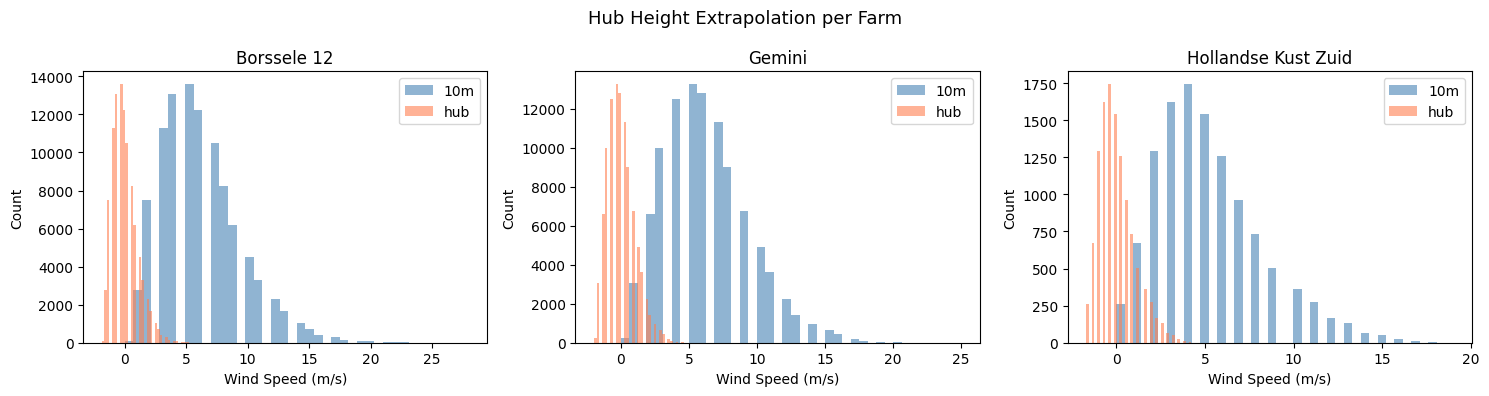

Saved: hub_height_comparison.png


In [36]:
#Visualization: Hub Height Comparison per Farm

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Hub Height Extrapolation per Farm", fontsize=13)

farms_to_plot = ["Borssele_12", "Gemini", "Hollandse_Kust_Zuid"]

for i, farm_id in enumerate(farms_to_plot):
    path = Path(f"../feature_engineering/features_{farm_id}.csv")
    if not path.exists():
        continue
    df = pd.read_csv(path, index_col=0)
    if "wind_speed_ms" in df.columns and "wind_speed_hub_ms" in df.columns:
        axes[i].hist(df["wind_speed_ms"],     bins=40, alpha=0.6, label="10m",     color="steelblue")
        axes[i].hist(df["wind_speed_hub_ms"], bins=40, alpha=0.6, label="hub",     color="coral")
        axes[i].set_title(farm_id.replace("_", " "))
        axes[i].set_xlabel("Wind Speed (m/s)")
        axes[i].set_ylabel("Count")
        axes[i].legend()

plt.tight_layout()
plt.savefig("hub_height_comparison.png", dpi=120)
plt.show()
print("Saved: hub_height_comparison.png")

In [ ]:
#this is to see what was added in feature engineering
# Original KNMI
original = pd.read_csv("../datasets/knmi_Vlissingen.csv",
                       parse_dates=["timestamp"], index_col="timestamp")

# Featured 
featured = pd.read_csv("../feature_engineering/features_Borssele_12.csv",
                       parse_dates=["timestamp"], index_col="timestamp")

print("ORIGINAL:")
print(f"  Shape: {original.shape}")
print(f"  Columns: {original.columns.tolist()}")
print()
print("FEATURED:")
print(f"  Shape: {featured.shape}")
print(f"  Columns: {featured.columns.tolist()}")
print()
print("NEW columns added:")
new_cols = [c for c in featured.columns if c not in original.columns]
print(f"  {new_cols}")
print()
print("Rows difference:")
print(f"  Original: {len(original)}")
print(f"  Featured: {len(featured)}")
print(f"  Dropped:  {len(original) - len(featured)}")

ORIGINAL:
  Shape: (100080, 22)
  Columns: ['Station', 'Station_ID', 'Source_Period', 'Source_File', 'wind_direction_deg', 'wind_direction_interpolated_deg', 'wind_dir_sin', 'wind_dir_cos', 'wind_speed_ms', 'wind_speed_10min_ms', 'wind_gust_ms', 'temperature_c', 'min_temp_10cm_c', 'dew_point_c', 'sunshine_duration_h', 'global_radiation_j_cm2', 'precip_duration_h', 'precipitation_mm', 'pressure_hpa', 'visibility_code', 'cloud_cover_octants', 'humidity_pct']

FEATURED:
  Shape: (100056, 40)
  Columns: ['Station', 'Station_ID', 'Source_Period', 'Source_File', 'wind_direction_deg', 'wind_direction_interpolated_deg', 'wind_dir_sin', 'wind_dir_cos', 'wind_speed_ms', 'wind_speed_10min_ms', 'wind_gust_ms', 'temperature_c', 'min_temp_10cm_c', 'dew_point_c', 'sunshine_duration_h', 'global_radiation_j_cm2', 'precip_duration_h', 'precipitation_mm', 'pressure_hpa', 'visibility_code', 'cloud_cover_octants', 'humidity_pct', 'wind_speed_hub_ms', 'wind_power_density', 'wind_speed_lag_1h', 'wind_speed_l